# Analyze imgep dataset
## Load datasets

In [1]:
import pickle
import numpy  as np
from exploration.load_file import load
from diversity.diversty import Diversity
import matplotlib.pyplot as plt

results/imgep_bandwidth_N_100000_k_1_1.pkl
results/random_bandwidth_expl_N_100000_2.pkl
diversity imgep 87210/10**18
diversity random 28250/10**18


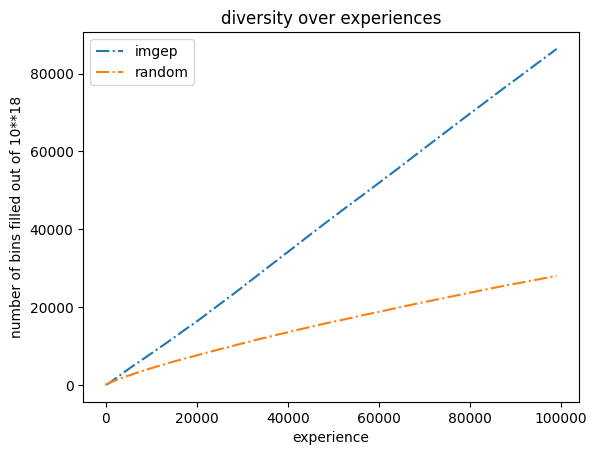

In [3]:
#Load data
folder = "results"
N = 100000
k=1
address_x = 5
print_freq = 1000
name_imgep = f'{folder}/imgep_bandwidth_N_{N}_k_{k}'
name_random = f'{folder}/random_bandwidth_expl_N_{N}'
content_imgep = load(name_imgep)
content_imgep_tab = content_imgep['numpy_view']
content_random = load(name_random)
content_random_tab = content_random['numpy_view']
dim_out = 18
#Compute diversity
##################################
min_tab = np.zeros((dim_out,))
max_tab = np.ones((dim_out,))*10

diversity_ = Diversity(min_tab = min_tab,
                        max_tab = max_tab,
                        num_bins = 20)

print(f'diversity imgep {diversity_(content_imgep_tab)}/10**{dim_out}')
diversity_imgep_list = [diversity_(content_imgep_tab[:print_freq*step]) for step in range(N//print_freq)]
plt.plot(range(0,N,print_freq),diversity_imgep_list,'-.',label="imgep")


print(f'diversity random {diversity_(content_random_tab)}/10**{dim_out}')

diversity_random_list = [diversity_(content_random_tab[:print_freq*step]) for step in range(N//print_freq)]
plt.plot(range(0,N,print_freq),diversity_random_list,'-.',label="random")
plt.legend()
plt.title('diversity over experiences')
plt.xlabel('experience')
plt.ylabel(f'number of bins filled out of 10**{dim_out}')
plt.show()

# faire courbe pourcentage en fonction nombre de bins

In [4]:
content_imgep['memory_observation'].keys()

dict_keys(['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff', 'bus_bandwidth_core_0_iso', 'bus_bandwidth_core_0_core1', 'ddr_bandwidth_core_0_iso', 'ddr_bandwidth_core_0_core1', 'time_core0_iso', 'time_core0_core1'])

## Attempt to identify clusters with UMAP
* The UMAP 4D projection of dataset isn't structured to be separated. However, 2 or 3 clusters are visible. 

* Projection with inferior dimension do not allow to discriminate consistent poles


In [5]:
##Attempt to reduce dimension - UMAP
import umap
from sklearn.cluster import HDBSCAN
#######################################################
data = np.array(content_imgep['numpy_view'])
#min max norm
print('data shape', data.shape)
print('min data',data.min(axis=0).shape)
data = (data - data.min(axis=0))/(1+ data.max(axis=0) - data.min(axis=0))

reducer = umap.UMAP(n_components=6,metric="euclidean")
embedding = reducer.fit_transform(data)

data shape (100000, 18)
min data (18,)


/home/ludovic/directory_env/envir/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


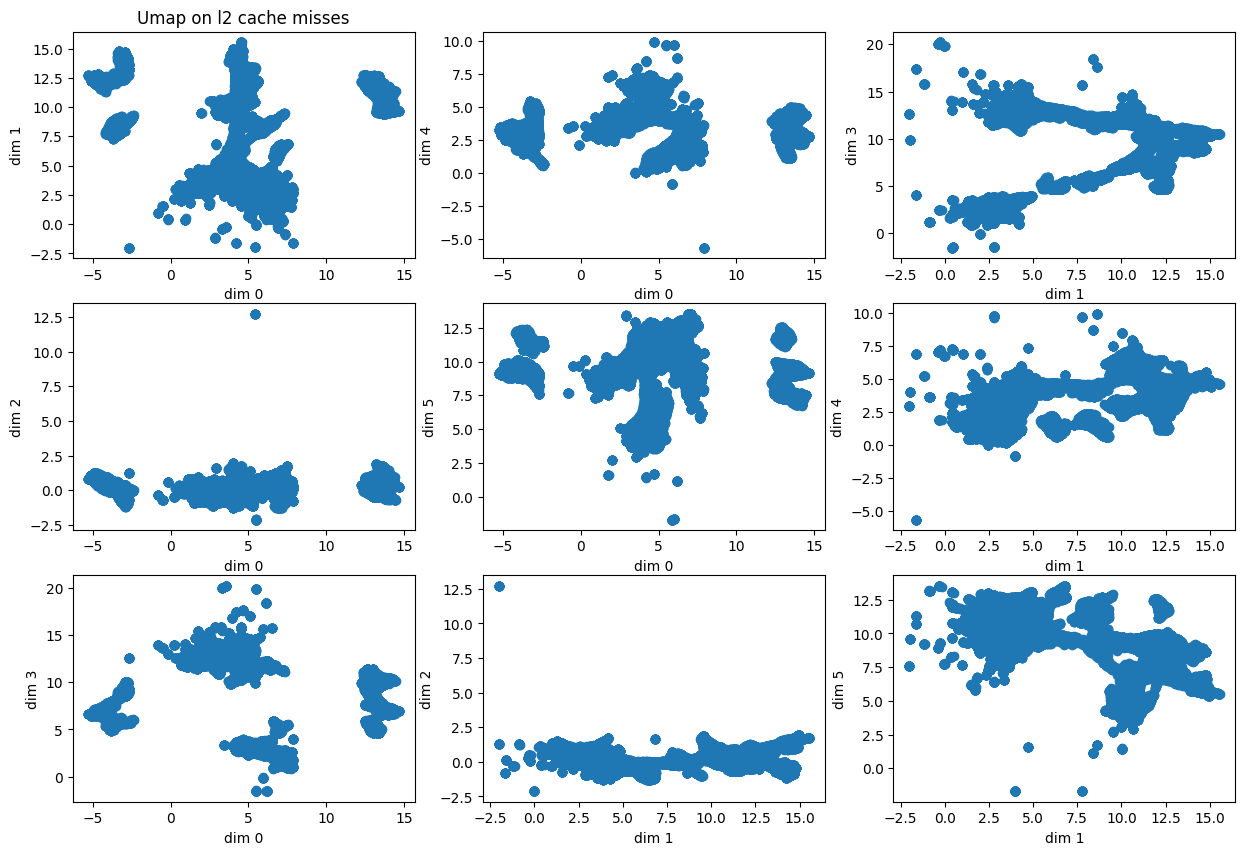

In [6]:
idx = [(i,j) for i in range(2) for j in range(i+1,6)]
fig,axs=plt.subplots(3,3,figsize=(15,10))

for j in range(len(idx)):
    axs[j%3,j//3].scatter(embedding[:,idx[j][0]],embedding[:,idx[j][1]])
    axs[j%3,j//3].set_xlabel(f'dim {idx[j][0]}')
    axs[j%3,j//3].set_ylabel(f'dim {idx[j][1]}')
    if j==0:
        axs[j%2,j//2].set_title('Umap on l2 cache misses')
plt.show()

In [7]:
len(idx)

9

In [15]:
hdb = HDBSCAN(copy=True, min_cluster_size=400)
hdb.fit(embedding)
print('hdb labels:',hdb.labels_)
print('labels',np.unique(hdb.labels_))

hdb labels: [ 5  5 -1 ...  4  4  4]
labels [-1  0  1  2  3  4  5  6]


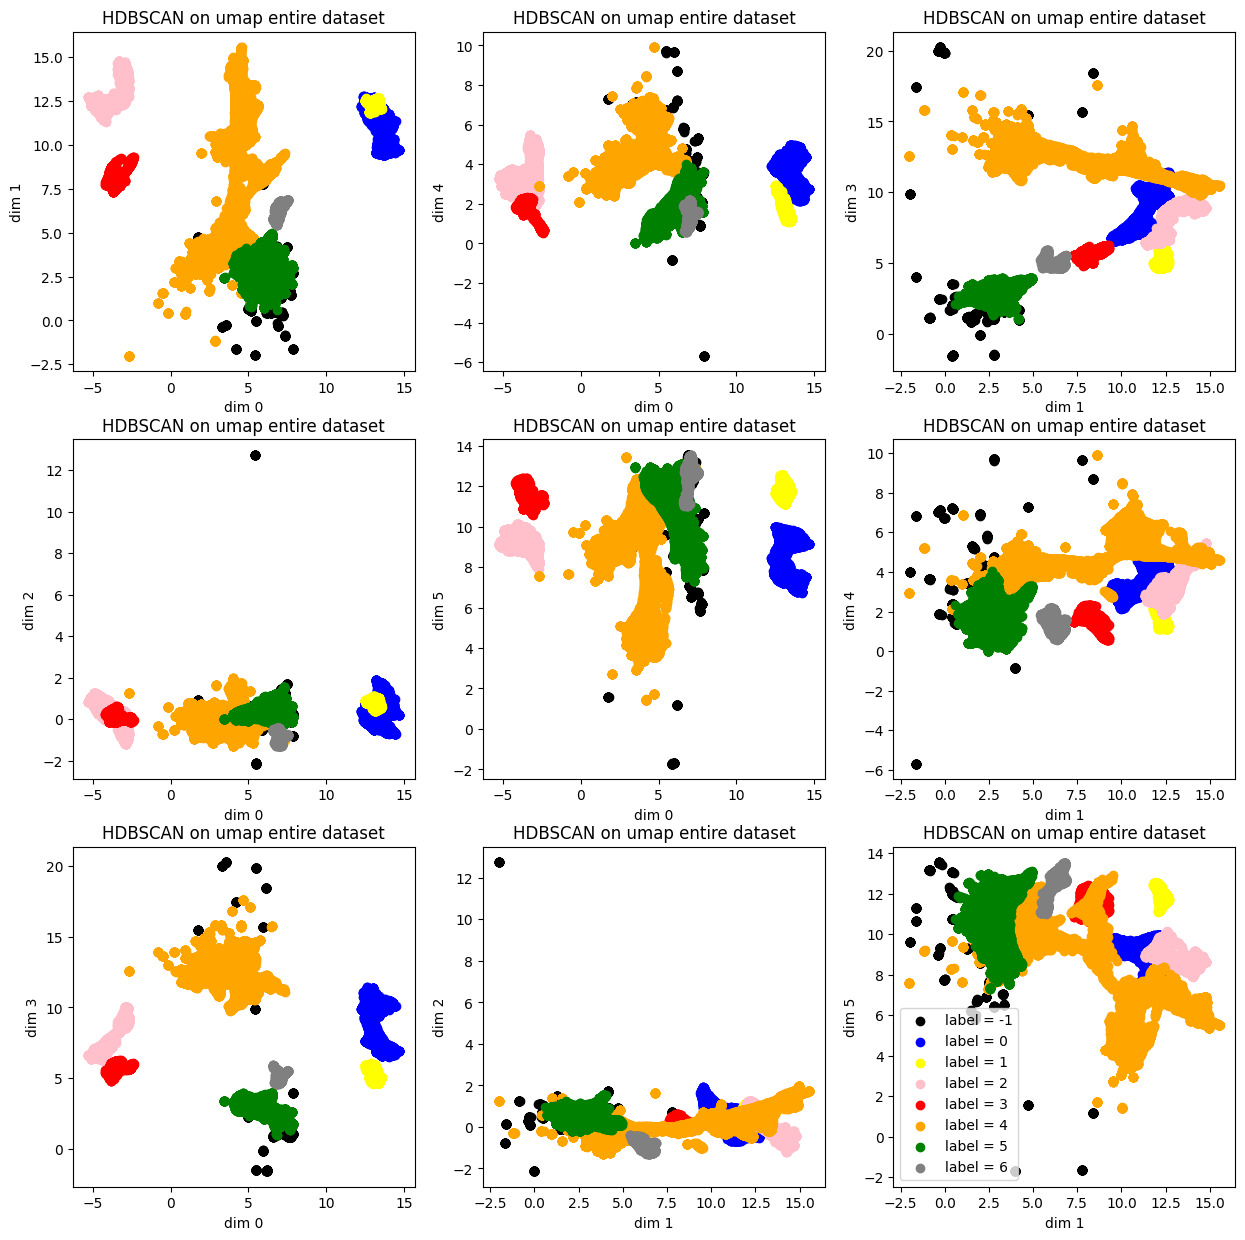

num elem label -1: 1167
num elem label 0: 12009
num elem label 1: 3080
num elem label 2: 10487
num elem label 3: 4596
num elem label 4: 47334
num elem label 5: 18434
num elem label 6: 2893


In [16]:
data_list = {key:[] for key in np.unique(hdb.labels_)}   
for j in range(N):
        data_list[hdb.labels_[j]].append(embedding[j])
fig,axs=plt.subplots(3,3,figsize=(15,15))
for i in range(len(idx)):
    for j,key in enumerate(data_list):
        axs[i%3,i//3].scatter(np.array(data_list[key])[:,idx[i][0]],np.array(data_list[key])[:,idx[i][1]],color = ['black','blue','yellow','pink','red','orange','green','gray','brown'][j],label=f'label = {key}')
        axs[i%3,i//3].set_title('HDBSCAN on umap entire dataset')
        axs[i%3,i//3].set_xlabel(f'dim {idx[i][0]}')
        axs[i%3,i//3].set_ylabel(f'dim {idx[i][1]}')
plt.legend()
plt.show()
for label in data_list:
    print(f'num elem label {label}: {len(data_list[label])}')

In [17]:
content_imgep.keys()

dict_keys(['memory_parameter', 'memory_observation', 'numpy_view'])

In [18]:
content_imgep['memory_observation'].keys()

dict_keys(['bus_bandwidth_core_0_diff', 'ddr_bandwidth_core_0_diff', 'cache_misses_l2_diff', 'bus_bandwidth_core_0_iso', 'bus_bandwidth_core_0_core1', 'ddr_bandwidth_core_0_iso', 'ddr_bandwidth_core_0_core1', 'time_core0_iso', 'time_core0_core1'])

In [21]:
clusters_imgep = {key:{feature:[] for feature in content_imgep['memory_observation'].keys()} for key in np.unique(hdb.labels_)}   
for j in range(N):
        for feature in content_imgep['memory_observation']:
            clusters_imgep[hdb.labels_[j]][feature].append(content_imgep['memory_observation'][feature][j])

In [37]:
allongements_mean  = []
allongements_var = []
for j in np.unique(hdb.labels_):
    #allongement = np.array(clusters_imgep[j]['time_core0_core1']) - np.array(clusters_imgep[j]['time_core0_iso'])
    allongement = np.array(clusters_imgep[j]['cache_misses_l2_diff'])
    mean_allongement = np.mean(allongement)
    print('mean',mean_allongement)
    print('var', np.var(allongement))
    allongements_mean.append(mean_allongement)

mean 0.6176806626678092
var 1.5920495764012748
mean 1.0856857356982264
var 5.454783582699075
mean 1.045995670995671
var 4.6341398095050685
mean 1.0927656463558055
var 5.482017846257608
mean 1.0653829416884246
var 4.820173866990709
mean 1.0805129505218236
var 5.037869152805482
mean 1.0250352609308886
var 3.7636584333521603
mean 0.9226869455006337
var 5.7328174836307095


Text(0.5, 0, 'clusters')

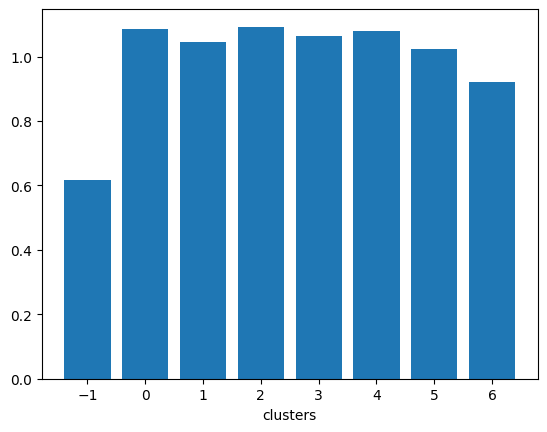

In [45]:
plt.figure()
plt.bar(np.unique(hdb.labels_),allongements_mean)
plt.xlabel('clusters')


### Some clusters seem too appear

## Attempt to identify clusters with Kmeans on untouched simulator data
--> sklearn website to
"Silhouette analysis can be used to study the separation distance between the resulting clusters. The silhouette plot displays a measure of how close each point in one cluster is to points in the neighboring clusters and thus provides a way to assess parameters like number of clusters visually. This measure has a range of [-1, 1].

Silhouette coefficients (as these values are referred to as) near +1 indicate that the sample is far away from the neighboring clusters. A value of 0 indicates that the sample is on or very close to the decision boundary between two neighboring clusters and negative values indicate that those samples might have been assigned to the wrong cluster."

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
for n_clusters in range(2,6):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto").fit(data)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(data, labels)
    print(
    "For n_clusters =",
    n_clusters,
    "The average silhouette_score is :",
    silhouette_avg,
    )

For n_clusters = 2 The average silhouette_score is : 0.434277985795954
For n_clusters = 3 The average silhouette_score is : 0.20044936577055486
For n_clusters = 4 The average silhouette_score is : 0.1351321324475596
For n_clusters = 5 The average silhouette_score is : 0.14453494894160507


### --> the values indicate pool clusters as they are far from 1.